# Regression with an Insurance Dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/sch2-reg-2026-d3-3/sample_submission.csv
/kaggle/input/competitions/sch2-reg-2026-d3-3/train.csv
/kaggle/input/competitions/sch2-reg-2026-d3-3/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv("/kaggle/input/competitions/sch2-reg-2026-d3-3/train.csv")
test=pd.read_csv("/kaggle/input/competitions/sch2-reg-2026-d3-3/test.csv")

In [4]:
print(train.shape)
print(test.shape)

(1200000, 21)
(800000, 20)


In [5]:
train.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [6]:
train.isnull().sum()

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [7]:
test.isnull().sum()

id                           0
Age                      12489
Gender                       0
Annual Income            29860
Marital Status           12336
Number of Dependents     73130
Education Level              0
Occupation              239125
Health Score             49449
Location                     0
Policy Type                  0
Previous Claims         242802
Vehicle Age                  3
Credit Score             91451
Insurance Duration           2
Policy Start Date            0
Customer Feedback        52276
Smoking Status               0
Exercise Frequency           0
Property Type                0
dtype: int64

In [8]:
df=pd.concat([train,test]) 

## EDA

In [9]:
df.isnull().sum()

id                           0
Age                      31194
Gender                       0
Annual Income            74809
Marital Status           30865
Number of Dependents    182802
Education Level              0
Occupation              597200
Health Score            123525
Location                     0
Policy Type                  0
Previous Claims         606831
Vehicle Age                  9
Credit Score            229333
Insurance Duration           3
Policy Start Date            0
Customer Feedback       130100
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount          800000
dtype: int64

In [10]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000000 entries, 0 to 799999
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Age                   float64
 2   Gender                object 
 3   Annual Income         float64
 4   Marital Status        object 
 5   Number of Dependents  float64
 6   Education Level       object 
 7   Occupation            object 
 8   Health Score          float64
 9   Location              object 
 10  Policy Type           object 
 11  Previous Claims       float64
 12  Vehicle Age           float64
 13  Credit Score          float64
 14  Insurance Duration    float64
 15  Policy Start Date     object 
 16  Customer Feedback     object 
 17  Smoking Status        object 
 18  Exercise Frequency    object 
 19  Property Type         object 
 20  Premium Amount        float64
dtypes: float64(9), int64(1), object(11)
memory usage: 335.7+ MB


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2000000.0,999999.500000,577350.413528,0.000000,499999.750000,999999.500000,1.499999e+06,1.999999e+06
Age,1968806.0,41.141914,13.539099,18.000000,30.000000,41.000000,5.300000e+01,6.400000e+01
Annual Income,1925191.0,32768.681192,32188.136083,1.000000,8021.000000,23957.000000,4.464100e+04,1.499970e+05
Number of Dependents,1817198.0,2.009695,1.416499,0.000000,1.000000,2.000000,3.000000e+00,4.000000e+00
Health Score,1876475.0,25.613559,12.204827,1.646561,15.918658,24.579581,3.452391e+01,5.897591e+01
Previous Claims,1393169.0,1.003562,0.982826,0.000000,0.000000,1.000000,2.000000e+00,9.000000e+00
Vehicle Age,1999991.0,9.570690,5.774592,0.000000,5.000000,10.000000,1.500000e+01,1.900000e+01
Credit Score,1770667.0,592.916507,150.035711,300.000000,468.000000,595.000000,7.210000e+02,8.490000e+02
Insurance Duration,1999997.0,5.018511,2.594102,1.000000,3.000000,5.000000,7.000000e+00,9.000000e+00
Premium Amount,1200000.0,1102.544822,864.998859,20.000000,514.000000,872.000000,1.509000e+03,4.999000e+03


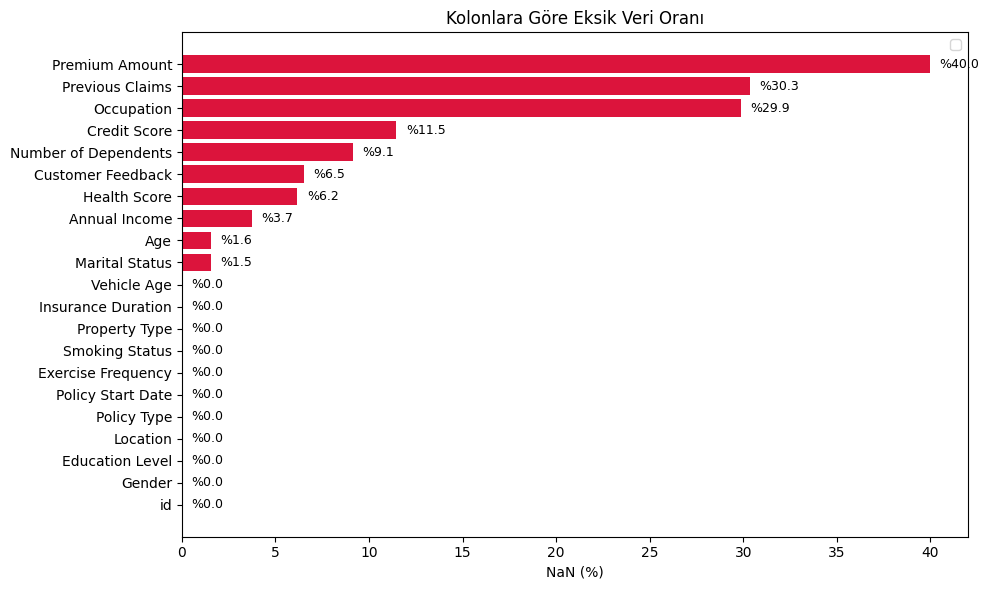

In [13]:
# NaN oranı
null = (df.isnull().mean() * 100).sort_values(ascending=True)

plt.figure(figsize=(10,6))

bars = plt.barh(null.index, null, color='#DC143C')

# Değerleri yaz
for i, v in enumerate(null):
    plt.text(v + 0.5, i, f"%{v:.1f}", va='center', fontsize=9)

plt.xlabel('NaN (%)')
plt.title('Kolonlara Göre Eksik Veri Oranı')
plt.legend()
plt.tight_layout()
plt.show()

## Data Processing & Feature Engineering

In [14]:
df.head(10)

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0
5,5,29.0,Male,45963.0,Married,1.0,Bachelor's,NaN,33.053198,Urban,...,2.0,4.0,614.0,5.0,2022-05-20 15:21:39.207847,Average,No,Weekly,House,3202.0
6,6,41.0,Male,40336.0,Married,0.0,PhD,NaN,NaN,Rural,...,2.0,8.0,807.0,6.0,2020-02-21 15:21:39.219432,Poor,No,Weekly,House,439.0
7,7,48.0,Female,127237.0,Divorced,2.0,High School,Employed,5.769783,Suburban,...,1.0,11.0,398.0,5.0,2022-08-08 15:21:39.181605,Average,No,Rarely,Condo,111.0
8,8,21.0,Male,1733.0,Divorced,3.0,Bachelor's,NaN,17.869551,Urban,...,1.0,10.0,685.0,8.0,2020-12-14 15:21:39.198406,Average,No,Monthly,Condo,213.0
9,9,44.0,Male,52447.0,Married,2.0,Master's,Employed,20.473718,Urban,...,1.0,9.0,635.0,3.0,2020-08-02 15:21:39.144722,Poor,No,Daily,Condo,64.0


In [15]:
# Numerik cols
train = df['Premium Amount'].notna()

num_cols = ['Age', 'Annual Income', 'Number of Dependents',
            'Health Score', 'Vehicle Age', 'Credit Score',
            'Insurance Duration']

df[num_cols] = df[num_cols].fillna(df.loc[train, num_cols].median())

In [16]:
# Previous Claims → flag + median
df['Previous_Claims_Missing'] = df['Previous Claims'].isna().astype(int)

df['Previous Claims'] = df['Previous Claims'].fillna(df.loc[train, 'Previous Claims'].median())

In [17]:
# Catregorical cols → train mode 
cat_cols = ['Marital Status', 'Customer Feedback']

df[cat_cols] = df[cat_cols].fillna(df.loc[train, cat_cols].mode().iloc[0])

In [18]:
# Occupation → Unknown
df['Occupation'] = df['Occupation'].fillna('Unknown')

In [19]:
df.drop(columns='Premium Amount').isnull().sum()

id                         0
Age                        0
Gender                     0
Annual Income              0
Marital Status             0
Number of Dependents       0
Education Level            0
Occupation                 0
Health Score               0
Location                   0
Policy Type                0
Previous Claims            0
Vehicle Age                0
Credit Score               0
Insurance Duration         0
Policy Start Date          0
Customer Feedback          0
Smoking Status             0
Exercise Frequency         0
Property Type              0
Previous_Claims_Missing    0
dtype: int64

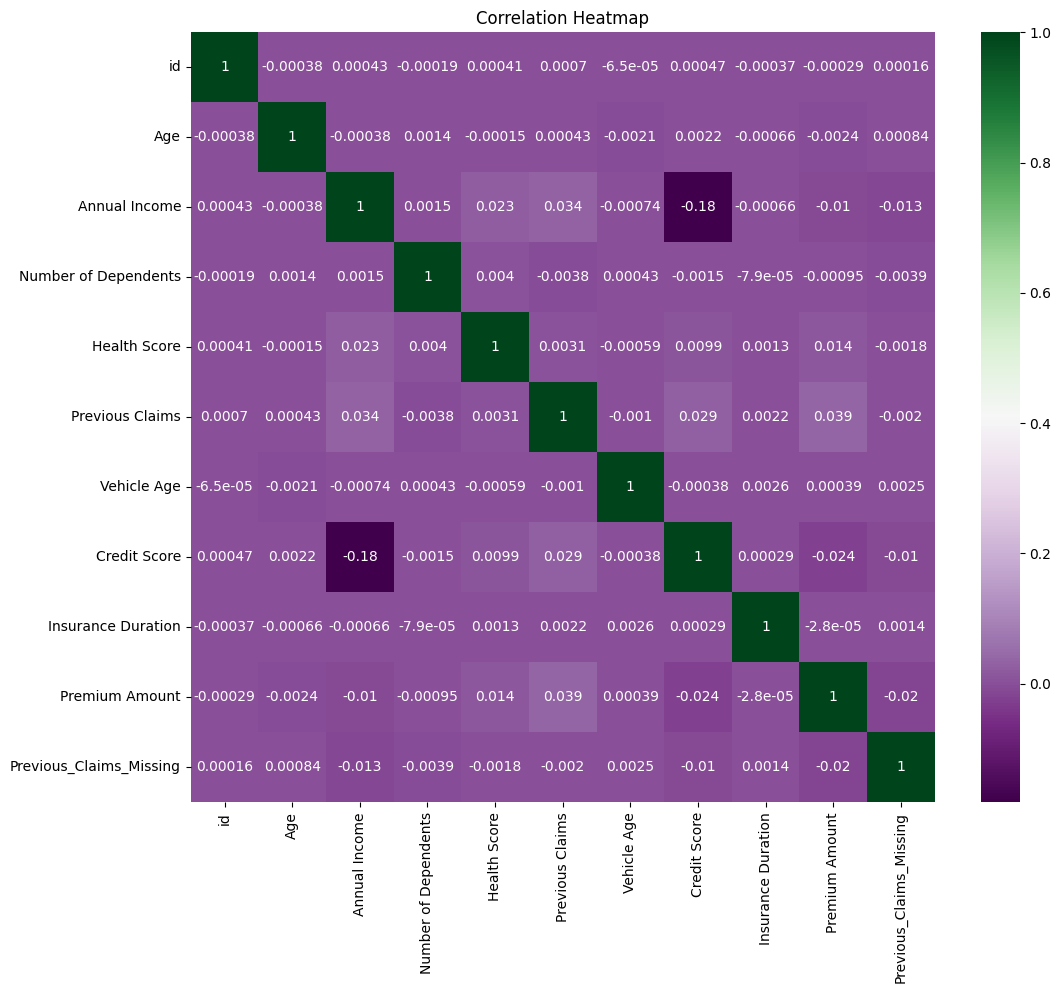

In [20]:
#Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='PRGn')
plt.title('Correlation Heatmap')
plt.show()

In [21]:
#Policy Start Date
df['Policy Start Date'] = pd.to_datetime(df['Policy Start Date'])

df['Policy_Year']        = df['Policy Start Date'].dt.year
df['Policy_Month']       = df['Policy Start Date'].dt.month
df['Policy_DayOfWeek']   = df['Policy Start Date'].dt.dayofweek  # 0=Pazartesi
df['Policy_Age_Days']    = (pd.Timestamp('2026-04-19') - df['Policy Start Date']).dt.days

df = df.drop(columns=['Policy Start Date'])

In [22]:
#Annual Income
df['Log_Annual_Income'] = np.log1p(df['Annual Income'])

In [23]:
# Kişi başı gelir (bağımlı sayısı arttıkça gerçek gelir azalır)
df['Income_Per_Person']     = df['Annual Income'] / (df['Number of Dependents'] + 1)

# Yıllık hasar oranı
df['Claims_Per_Year']       = df['Previous Claims'] / df['Insurance Duration']

# Yaş × Sağlık skoru (risk proxy)
df['Age_Health_Interaction'] = df['Age'] * df['Health Score']

# Gelir / Kredi skoru 
df['Income_Credit_Ratio']   = df['Annual Income'] / (df['Credit Score'] + 1)

# Araç yaşı + sigorta süresi (toplam risk süresi)
df['Total_Risk_Duration']   = df['Vehicle Age'] + df['Insurance Duration']

In [24]:
# Binary cols
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Smoking Status'] = df['Smoking Status'].map({'No': 0, 'Yes': 1})

In [25]:
# Ordinal cols
education      = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
feedback       = {'Poor': 0, 'Average': 1, 'Good': 2}
exercise       = {'Rarely': 0, 'Monthly': 1, 'Weekly': 2, 'Daily': 3}

df['Education Level']    = df['Education Level'].map(education)
df['Customer Feedback']  = df['Customer Feedback'].map(feedback)
df['Exercise Frequency'] = df['Exercise Frequency'].map(exercise)

In [26]:
# Nominal cols — One-Hot Encoding

nominal_cols = ['Marital Status', 'Occupation', 'Location',
                'Policy Type', 'Property Type']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [27]:
df.columns.tolist()

['id',
 'Age',
 'Gender',
 'Annual Income',
 'Number of Dependents',
 'Education Level',
 'Health Score',
 'Previous Claims',
 'Vehicle Age',
 'Credit Score',
 'Insurance Duration',
 'Customer Feedback',
 'Smoking Status',
 'Exercise Frequency',
 'Premium Amount',
 'Previous_Claims_Missing',
 'Policy_Year',
 'Policy_Month',
 'Policy_DayOfWeek',
 'Policy_Age_Days',
 'Log_Annual_Income',
 'Income_Per_Person',
 'Claims_Per_Year',
 'Age_Health_Interaction',
 'Income_Credit_Ratio',
 'Total_Risk_Duration',
 'Marital Status_Married',
 'Marital Status_Single',
 'Occupation_Self-Employed',
 'Occupation_Unemployed',
 'Occupation_Unknown',
 'Location_Suburban',
 'Location_Urban',
 'Policy Type_Comprehensive',
 'Policy Type_Premium',
 'Property Type_Condo',
 'Property Type_House']

## Train Test Split

In [28]:
drop_cols = ['Policy_Year', 'Policy_Age_Days', 
             'Policy_Month', 'Policy_DayOfWeek',
             'Annual Income', 
             'Premium Amount', 'id',
             'Income_Per_Person']

In [29]:
train = df[df['Premium Amount'].notna()]
test  = df[df['Premium Amount'].isna()]

In [30]:
x     = train.drop(columns=drop_cols)
y     = train['Premium Amount']


x_final_test = test.drop(columns=drop_cols)

## Model Training

In [31]:
def algo_test(x, y):

    # ── Modeller ──────────────────────────────────────────
    linear_models = {
        'LinearRegression' : LinearRegression(),
        'Ridge'            : Ridge(),
        'Lasso'            : Lasso(),
        'ElasticNet'       : ElasticNet(),
        'KNeighbors'       : KNeighborsRegressor(),
    }

    tree_models = {
        'ExtraTrees'       : ExtraTreesRegressor(n_jobs=-1, random_state=42),
        'GradientBoosting' : GradientBoostingRegressor(random_state=42),
        'DecisionTree'     : DecisionTreeRegressor(random_state=42),
        'XGBoost'          : XGBRegressor(n_jobs=-1, random_state=42, verbosity=0),
    }

    # ── Train/Test Ayır ───────────────────────────────────
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42 )

    # ── Linear modeller için Scaling ──────────────────────
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled  = scaler.transform(x_test)

    # ── Sonuç tablosu ─────────────────────────────────────
    results = []

    for name, model in linear_models.items():
        model.fit(x_train_scaled, y_train)
        p = model.predict(x_test_scaled)
        results.append({
            'Model' : name,
            'R²'    : round(r2_score(y_test, p), 4),
            'RMSE'  : round(mean_squared_error(y_test, p) ** 0.5, 2),
            'MAE'   : round(mean_absolute_error(y_test, p), 2)
        })
        print(f"✅ {name} tamamlandı")

    for name, model in tree_models.items():
        model.fit(x_train, y_train)
        p = model.predict(x_test)
        results.append({
            'Model' : name,
            'R²'    : round(r2_score(y_test, p), 4),
            'RMSE'  : round(mean_squared_error(y_test, p) ** 0.5, 2),
            'MAE'   : round(mean_absolute_error(y_test, p), 2)
        })
        print(f"✅ {name} tamamlandı")

    # ── R²'ye göre sıralı döndür ──────────────────────────
    result_df = pd.DataFrame(results).set_index('Model')
    return result_df.sort_values('R²', ascending=False)

In [32]:
algo_test(x, y)

✅ LinearRegression tamamlandı
✅ Ridge tamamlandı
✅ Lasso tamamlandı
✅ ElasticNet tamamlandı
✅ KNeighbors tamamlandı
✅ ExtraTrees tamamlandı
✅ GradientBoosting tamamlandı
✅ DecisionTree tamamlandı
✅ XGBoost tamamlandı


,R²,RMSE,MAE
Model,,,
XGBoost,0.0380,847.89,646.45
GradientBoosting,0.0260,853.13,656.41
ExtraTrees,0.0107,859.82,668.69
Lasso,0.0039,862.79,667.01
LinearRegression,0.0038,862.80,667.01
Ridge,0.0038,862.80,667.01
ElasticNet,0.0033,863.05,667.28
KNeighbors,-0.1807,939.32,720.77
DecisionTree,-1.0540,1238.93,902.07


In [33]:
# Log transform 
y_log = np.log1p(y)  

In [34]:
results_log = algo_test(x, y_log)
print(results_log)

✅ LinearRegression tamamlandı
✅ Ridge tamamlandı
✅ Lasso tamamlandı
✅ ElasticNet tamamlandı
✅ KNeighbors tamamlandı
✅ ExtraTrees tamamlandı
✅ GradientBoosting tamamlandı
✅ DecisionTree tamamlandı
✅ XGBoost tamamlandı
                      R²  RMSE   MAE
Model                               
XGBoost           0.0696  1.06  0.75
GradientBoosting  0.0637  1.06  0.76
ExtraTrees        0.0447  1.07  0.77
LinearRegression  0.0088  1.09  0.80
Ridge             0.0088  1.09  0.80
Lasso            -0.0000  1.10  0.80
ElasticNet       -0.0000  1.10  0.80
KNeighbors       -0.1745  1.19  0.88
DecisionTree     -1.0103  1.55  1.12


In [35]:
best_model = XGBRegressor(n_jobs=-1, random_state=42, verbosity=0)
best_model.fit(x, y_log)                        

prediction_log = best_model.predict(x_final_test)
prediction     = np.expm1(prediction_log)     

In [36]:
submission = pd.DataFrame({
    'id'             : test['id'],
    'Premium Amount' : prediction
})

In [37]:
submission.head()

,id,Premium Amount
0,1200000,732.407593
1,1200001,879.625122
2,1200002,780.575806
3,1200003,807.606567
4,1200004,721.236145


In [38]:
submission.to_csv('submission.csv', index=False)